In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("iris.csv")
df

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...,...
145,146,6.7,3.0,5.2,2.3,Iris-virginica
146,147,6.3,2.5,5.0,1.9,Iris-virginica
147,148,6.5,3.0,5.2,2.0,Iris-virginica
148,149,6.2,3.4,5.4,2.3,Iris-virginica


In [3]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


Id                  Axes(0.125,0.53;0.227941x0.35)
SepalLengthCm    Axes(0.398529,0.53;0.227941x0.35)
SepalWidthCm     Axes(0.672059,0.53;0.227941x0.35)
PetalLengthCm       Axes(0.125,0.11;0.227941x0.35)
PetalWidthCm     Axes(0.398529,0.11;0.227941x0.35)
dtype: object

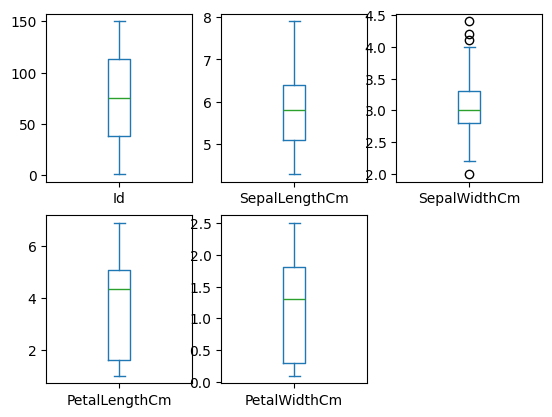

In [4]:
#outliers of all columns in one 
df.plot(kind="box",subplots=True,layout=(2,3))


<Axes: xlabel='SepalWidthCm', ylabel='Count'>

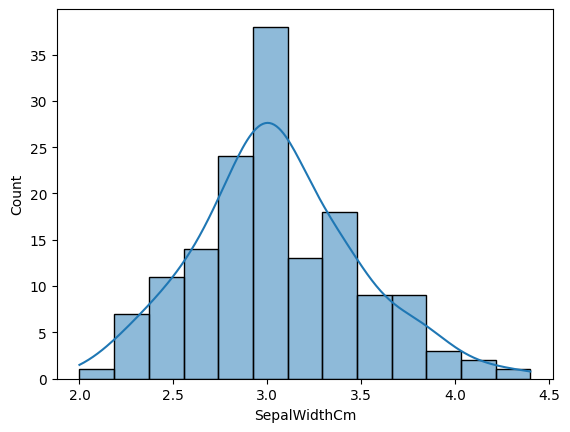

In [12]:
#histogram of dataset
sns.histplot(df["SepalWidthCm"],kde=True)

In [13]:
#iqr for sepal width
q1=df["SepalWidthCm"].quantile(0.25)
q3=df["SepalWidthCm"].quantile(0.75)
iqr=q3-q1
lower_bound=q1-1.5*iqr
upper_bound=q3+1.5*iqr
df["SepalWidthCm"].clip(lower_bound,upper_bound,inplace=True)

C:\Users\91998\AppData\Local\Temp\ipykernel_24428\535274789.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SepalWidthCm"].clip(lower_bound,upper_bound,inplace=True)


Id                  Axes(0.125,0.53;0.227941x0.35)
SepalLengthCm    Axes(0.398529,0.53;0.227941x0.35)
SepalWidthCm     Axes(0.672059,0.53;0.227941x0.35)
PetalLengthCm       Axes(0.125,0.11;0.227941x0.35)
PetalWidthCm     Axes(0.398529,0.11;0.227941x0.35)
dtype: object

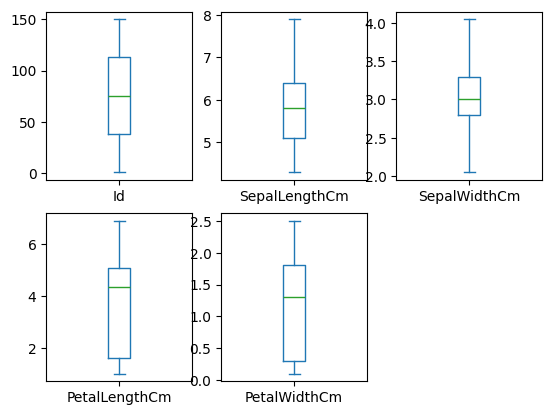

In [14]:
df.plot(kind="box",subplots=True,layout=(2,3))

In [16]:
#to check missing values
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [17]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [26]:
x=df.drop("Species",axis=1)
y=df["Species"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
from sklearn.svm import SVC
model=SVC(kernel="rbf",C=1.0,gamma="scale",degree=3,probability=True)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print("training accuracy:",model.score(x_train,y_train))
print("testing accuracy:",model.score(x_test,y_test))

training accuracy: 0.9916666666666667
testing accuracy: 1.0


In [27]:
#classification report and confusion matrix
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


In [28]:
#comparing the actual and predicted values
df_comparison=pd.DataFrame({"Actual":y_test,"Predicted":y_pred})
df_comparison

,Actual,Predicted
73,Iris-versicolor,Iris-versicolor
18,Iris-setosa,Iris-setosa
118,Iris-virginica,Iris-virginica
78,Iris-versicolor,Iris-versicolor
76,Iris-versicolor,Iris-versicolor
31,Iris-setosa,Iris-setosa
64,Iris-versicolor,Iris-versicolor
141,Iris-virginica,Iris-virginica
68,Iris-versicolor,Iris-versicolor
82,Iris-versicolor,Iris-versicolor
